In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import numpy as np
import random
import re
from pathlib import Path
from difflib import SequenceMatcher
import gzip

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations

import warnings
warnings.filterwarnings('ignore')

# Step 1: Extract treatment and control groups

#### Extract diagnoses info for a subset

In [4]:
from pathlib import Path
import gzip
from typing import Dict, List, Optional, Set, Union

def load_dx2_diagnoses(
    base_dir: Union[str, Path],
    *,
    cases_dir: Optional[Union[str, Path]] = None,
    restrict_to_cases: bool = True,
    shard_range=range(12),
    dx_subdir: str = "anns/dx2",
    pattern: str = "PMC*_body.txt.bsv.gz",
    encoding: str = "utf-8",
) -> Dict[str, List[str]]:
    """
    Load diagnosis annotations from gzipped BSV files under a sharded PMC directory structure.

    Args:
      base_dir: root directory containing folders like PMC000xxxxxx/anns/dx2/
      cases_dir: directory containing case report files like PMC*_body.txt (used to restrict)
      restrict_to_cases: if True and cases_dir provided, only keep IDs in cases_dir
      shard_range: which shard folders to scan (default range(12) => PMC000xxxxxx..PMC011xxxxxx)
      dx_subdir: relative path within each shard folder to dx annotations
      pattern: filename glob under dx_subdir
      encoding: text encoding for gzip reading

    Returns:
      dict mapping base_id (e.g., 'PMC3075162_body') -> list of diagnoses (strings)
    """
    base_dir = Path(base_dir).expanduser().resolve()

    case_ids: Optional[Set[str]] = None
    if cases_dir is not None:
        cases_dir = Path(cases_dir).expanduser().resolve()
        # Build the subset list from case reports
        case_files = list(cases_dir.glob("PMC*_body.txt"))
        case_ids = {f.stem for f in case_files}

    diagnosis_data: Dict[str, List[str]] = {}

    for i in shard_range:
        folder = base_dir / f"PMC{i:03d}xxxxxx" / dx_subdir
        if not folder.exists():
            print(f"⚠️ Skipping missing folder: {folder}")
            continue

        for ann_file in folder.glob(pattern):
            base = ann_file.name.replace(".txt.bsv.gz", "")

            if restrict_to_cases and case_ids is not None and base not in case_ids:
                continue

            diagnoses: List[str] = []
            with gzip.open(ann_file, "rt", encoding=encoding) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    # Your original used tab; keep same:
                    parts = line.split("\t")
                    if parts and parts[0]:
                        diagnoses.append(parts[0])

            if diagnoses:
                diagnosis_data[base] = diagnoses

    return diagnosis_data


diagnosis_data = load_dx2_diagnoses(
    base_dir="/Users/kumars33/Desktop/CHARM_MIMIC/l33_pmc_anns/",
    cases_dir=None,
    restrict_to_cases=False,
)

diagnosis_data_glp = load_dx2_diagnoses(
    base_dir="/Users/kumars33/Desktop/CHARM_MIMIC/l33_pmc_anns/",
    cases_dir="/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/case_reports_n140/",
    restrict_to_cases=True,
)

for key, value in list(diagnosis_data.items())[:5]:  # Show first 5 entries
    print(f"File: {key}, Diagnosis: {value}")

for key, value in list(diagnosis_data_glp.items())[:5]:  # Show first 5 entries
    print(f"File: {key}, Diagnosis: {value}")


File: PMC545954.txt_body, Diagnosis: ['Mucinous cystadenocarcinoma', 'Dermoid cyst']
File: PMC547911.txt_body, Diagnosis: ['Enterococcal meningitis', 'Rheumatoid arthritis', 'Insulin-dependent diabetes', 'Moderate renal failure', 'Bowel erosions']
File: PMC548304.txt_body, Diagnosis: ['Ulcerative colitis', 'Clostridium difficile infection', 'Spondyloarthropathy', 'Dental abscess']
File: PMC552326.txt_body, Diagnosis: ['Subcutaneous leiomyosarcoma']
File: PMC552333.txt_body, Diagnosis: ['Adenocarcinoma of the distal oesophagus', 'Metastatic oesophageal adenocarcinoma to the bladder']
File: PMC3075162_body, Diagnosis: ['Tropical calcific pancreatitis', 'Acute suppuration of the pancreatic duct', 'Non-insulin-dependent diabetes mellitus', 'Exocrine pancreatic insufficiency', 'Septicemia', 'Acute respiratory distress syndrome', 'Multiorgan failure']
File: PMC3329809_body, Diagnosis: ['HIV infection', 'Type 2 diabetes']
File: PMC4578500_body, Diagnosis: ['Prader–Willi syndrome', 'Diabetes m

In [5]:
import re

diabetes_keywords = ['diabetes', 'diabetic', 'dm', 'type 1', 'type 2', 'insulin', 'metabolic syndrome', 'hyperglycem', 'hypoglycem', 
                     'ketoacidosis', 'hba1c']

# Compile one regex for speed; use word boundaries for "dm" to avoid matching "admission" etc.
# Everything else is substring-like (diabetes, hyperglycem, etc.)
pattern = re.compile(
    r"(" +
    r"\bdm\b" + "|" +
    "|".join(re.escape(k) for k in diabetes_keywords if k != "dm") +
    r")",
    flags=re.IGNORECASE
)

def files_with_diabetes(dx_dict):
    """
    dx_dict examples:
      {"PMC3329809_body": ["HIV infection", "Type 2 diabetes"], ...}
    Returns:
      matched_files (sorted list), count
    """
    matched = []
    for fname, diagnoses in dx_dict.items():
        # be robust if diagnoses is None or a single string
        if diagnoses is None:
            continue
        if isinstance(diagnoses, str):
            diagnoses = [diagnoses]

        if any(pattern.search(str(d)) for d in diagnoses):
            matched.append(fname)

    matched.sort()
    return matched

# Example usage:
matched_diabetes_files_all= files_with_diabetes(diagnosis_data)
matched_diabetes_files_glp= files_with_diabetes(diagnosis_data_glp)

print("Number of total files from PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_all)))
print("Number of total files from GLP-PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_glp)))


#### Identify which exact keywords triggered the match
# import re

# def files_with_keyword_and_diagnoses(dx_dict, pattern: re.Pattern):
#     """
#     Returns:
#       {
#         filename: {
#           matched_keyword: [diagnosis1, diagnosis2, ...],
#           ...
#         },
#         ...
#       }
#     """
#     out = {}
#     for fname, diagnoses in dx_dict.items():
#         if diagnoses is None:
#             continue
#         if isinstance(diagnoses, str):
#             diagnoses = [diagnoses]

#         hit_map = {}  # keyword -> set(diagnoses)
#         for d in diagnoses:
#             d_str = str(d)
#             for m in pattern.finditer(d_str):
#                 kw = m.group(0).lower()
#                 hit_map.setdefault(kw, set()).add(d_str)

#         if hit_map:
#             # convert sets to sorted lists for stable output
#             out[fname] = {kw: sorted(list(ds)) for kw, ds in hit_map.items()}

#     return out

# triggers = files_with_keyword_and_diagnoses(diagnosis_data, pattern)

#*****************************************

diabetes_non_glp = list({x for x in matched_diabetes_files_all if x not in set(matched_diabetes_files_glp)})  # unique; drop set() if you want duplicates preserved

pmoa_n25k = [p.stem for p in Path("/Users/kumars33/Desktop/CHARM_MIMIC/L33_survival_analysis_25k/sampled_25k_body/clean/").glob("*.txt")]
diabetes_non_glp = list({x for x in diabetes_non_glp if x in set(pmoa_n25k)})

matched_diabetes_files_nonglp_eqsubset = random.Random(0).sample(diabetes_non_glp, k=len(matched_diabetes_files_glp))

diagnosis_control_diabetes_nonglp = {k: v for k, v in diagnosis_data.items() if k in matched_diabetes_files_nonglp_eqsubset}
diagnosis_case_diabetes_glp = {k: v for k, v in diagnosis_data_glp.items() if k in matched_diabetes_files_glp}


Number of total files from PMOA with diabetes keywords:12615
Number of total files from GLP-PMOA with diabetes keywords:120


### Filter out GLP case reports from treatment group where GLP medication time >= 72 hours

In [7]:
import os
import re
import csv
from typing import Iterable, Dict, List, Optional, Any

GLP_KEYWORDS: List[str] = ["glp1", "glp 1 receptor agonist", "glp 1 analog", "glp 1 ra", "glucagon like peptide 1", "semaglutide", 
                           "liraglutide","exenatide","dulaglutide","lixisenatide","albiglutide","efpeglenatide","tirzepatide","ozempic",
                           "rybelsus","wegovy","saxenda","victoza","byetta","bydureon","trulicity","adlyxin","tanzeum","zepbound","mounjaro"]

def _safe_float(x: object) -> Optional[float]:
    try:
        return float(str(x).strip())
    except Exception:
        return None

def classify_glp_cases_with_debug(
    filename_list: Iterable[str],   # stems, no .csv
    csv_folder: str,
    glp_keywords: List[str] = GLP_KEYWORDS,
    time_threshold_hours: float = 96.0,
    encoding: str = "utf-8",
    case_insensitive_filename_match: bool = True,
    collect_all_matches: bool = True,
) -> Dict[str, Dict[str, Any]]:
    """
    Returns:
      {
        "<stem>": {
          "is_case": 0/1,
          "matched_file": "<actual filename in folder>",
          "threshold_hours": 168.0,
          "glp_hits": [
              {
                "row_index": <1-based row number excluding header>,
                "event": "<full event cell text>",
                "matched_keywords": ["...", ...],
                "time_raw": "<raw time cell>",
                "time_parsed": <float or None>,
                "within_threshold": True/False/None,
              }, ...
          ]
        }, ...
      }

    Decision rule:
      is_case = 1 if ANY hit has time_parsed != None AND time_parsed <= threshold_hours.
    """

    stems = [os.path.basename(f) for f in filename_list]
    if case_insensitive_filename_match:
        stem_set = {s.lower() for s in stems}
        def stem_matches(file_stem: str) -> bool:
            return file_stem.lower() in stem_set
    else:
        stem_set = set(stems)
        def stem_matches(file_stem: str) -> bool:
            return file_stem in stem_set

    # Regex to find which keywords matched (case-insensitive).
    # We'll use finditer so we can report actual matched substrings.
    kw_pattern = re.compile(
        "(" + "|".join(re.escape(k) for k in glp_keywords if k and k.strip()) + ")",
        flags=re.IGNORECASE,
    )

    out: Dict[str, Dict[str, Any]] = {}

    for entry in os.listdir(csv_folder):
        if not entry.lower().endswith(".csv"):
            continue

        file_stem, _ = os.path.splitext(entry)
        if not stem_matches(file_stem):
            continue

        path = os.path.join(csv_folder, entry)
        hits: List[Dict[str, Any]] = []
        is_case = 0

        with open(path, "r", encoding=encoding, newline="") as f:
            reader = csv.DictReader(f)
            if not reader.fieldnames:
                out[file_stem] = {
                    "is_case": 0,
                    "matched_file": entry,
                    "threshold_hours": time_threshold_hours,
                    "glp_hits": [],
                    "note": "Empty CSV or missing header/rows.",
                }
                continue

            field_map = {name.strip().lower(): name for name in reader.fieldnames}
            if "event" not in field_map or "time" not in field_map:
                raise ValueError(
                    f"{entry} missing required columns 'event' and 'time'. Found: {reader.fieldnames}"
                )

            event_col = field_map["event"]
            time_col = field_map["time"]

            for idx, row in enumerate(reader, start=1):  # start=1 for 1-based row count (excluding header)
                event_val = (row.get(event_col) or "")
                if not event_val:
                    continue

                # Find all keyword matches within the event text
                matches = [m.group(0) for m in kw_pattern.finditer(event_val)]
                if not matches:
                    continue

                time_raw = row.get(time_col)
                time_parsed = _safe_float(time_raw)

                within: Optional[bool]
                if time_parsed is None:
                    within = None
                else:
                    within = (time_parsed <= time_threshold_hours)

                hit = {
                    "row_index": idx,
                    "event": event_val,
                    "matched_keywords": sorted(set(matches), key=str.lower),
                    "time_raw": time_raw,
                    "time_parsed": time_parsed,
                    "within_threshold": within,
                }
                hits.append(hit)

                # Decision rule: any qualifying time => case
                if within is True:
                    is_case = 1
                    if not collect_all_matches:
                        break  # stop reading rows early

            # If we broke early, we might want to skip remaining rows
            # but only inside this file.
            # (If collect_all_matches=False and is_case=1, we're done.)

        out[file_stem] = {
            "is_case": is_case,
            "matched_file": entry,
            "threshold_hours": time_threshold_hours,
            "glp_hits": hits,
        }

    return out

# Convenience: collapse the debug output into the simple dict you originally wanted
def to_simple_is_case(debug_result: Dict[str, Dict[str, Any]]) -> Dict[str, int]:
    return {stem: int(info.get("is_case", 0)) for stem, info in debug_result.items()}

In [8]:
#result = classify_glp_cases(matched_diabetes_files_glp, "/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/manual_anns_n140_task2/best_performer")

#"/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/clean_csv/"
#"/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/manual_anns_n140_task2/best_performer/"

debug = classify_glp_cases_with_debug(matched_diabetes_files_glp, csv_folder="/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/clean_csv/")
simple = to_simple_is_case(debug)

#print(list(simple.values()).count(1))

##Collect all parsed times from GLP hits (optionally only those within threshold)
# matched_times = [
#     hit["time_parsed"]
#     for info in debug.values()
#     for hit in info.get("glp_hits", [])
#     if hit.get("time_parsed") is not None
# ]

# plt.figure()
# plt.hist(matched_times, bins=30)
# plt.xlabel("GLP medication time (hours)")
# plt.ylabel("Count")
# plt.title("Histogram of matched GLP medication times")
# plt.show()


print("Number of files from PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_all)))
print("Number of files from GLP-PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_glp)))

final_case_files = ([k for k,v in simple.items() if v == 1])

#final_control_files = random.Random(0).sample(diabetes_non_glp, k=len(final_case_files))

case_should_be_controls = [k for k,v in simple.items() if v == 0]

final_control_files = []
final_control_files.append([k for k,v in simple.items() if v == 0])
final_control_files.append(random.Random(0).sample(diabetes_non_glp, k=len(final_case_files) - len([k for k,v in simple.items() if v == 0])))

final_control_files = [item for sublist in final_control_files for item in sublist]

print('Number of case reports in treatment group selected after filtering GLP times: {}'.format(len(final_case_files)))
print('Number of case reports in control group randomly selected as equal subset: {}'.format(len(final_control_files)))

#################################
# final_control_files = random.Random(0).sample(diabetes_non_glp, k=len(final_case_files))

# diagnosis_control_diabetes_nonglp = {k: v for k, v in diagnosis_data.items() if k in final_control_files}
# diagnosis_case_diabetes_glp = {k: v for k, v in diagnosis_data_glp.items() if k in final_case_files}

#set(final_case_files).intersection(set(final_control_files))


Number of files from PMOA with diabetes keywords:12615
Number of files from GLP-PMOA with diabetes keywords:120
Number of case reports in treatment group selected after filtering GLP times: 82
Number of case reports in control group randomly selected as equal subset: 82


In [9]:
len(final_control_files)

82

# Step 2: Disease onset with times (GPT5 generated)

In [11]:
def create_disease_onset_df(bsv_folder):

    # X = final_case_files  # e.g., ["123", "456"]
    # Y = final_control_files  # e.g., ["789", "999"]
    
    # # where to save matched BSV files
    # out_X = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/history_onset/treatment_group/")
    # out_Y = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/history_onset/control_group/")
    # out_X.mkdir(parents=True, exist_ok=True)
    # out_Y.mkdir(parents=True, exist_ok=True)

    def parse_time_to_float(t: str):
        t = t.strip()
        try:
            return float(t.replace("+", ""))
        except Exception:
            return None

    def extract_disease_onset_pairs(text: str):
        pairs = []
        for line in text.splitlines():
            if re.search(r"^\s*Disease\s+onset\s*=", line, flags=re.IGNORECASE):
                rhs = line.split("=", 1)[1].strip()
                parts = [p.strip() for p in rhs.split("|") if p.strip() != ""]
                for i in range(0, len(parts) - 1, 2):
                    pairs.append((parts[i], parts[i + 1]))
                break
        return pairs
    
    def stem(name: str) -> str:
        """Normalize to filename stem (no extension), regardless of how X/Y are formatted."""
        base = Path(name).name
        return base.rsplit(".", 1)[0]


    rows = []
    disease_onset_dict = {}  # filename -> list of {"disease_onset": str, "time": float|str}
    
    for fp in sorted(bsv_folder.glob("*")):
        if fp.is_dir():
            continue
    
        text = fp.read_text(encoding="utf-8", errors="replace")
        pairs = extract_disease_onset_pairs(text)
    
        fname = fp.name
        fstem = fp.stem
        disease_onset_dict[fname] = []
    
        # If no pairs found, still record a row
        if not pairs:
            rows.append({"filename": fname, "disease_onset": "None reported", "time": "None reported"})
            disease_onset_dict[fname].append({"disease_onset": "None reported", "time": "None reported"})
        else:
            for event, time_str in pairs:
                t_val = parse_time_to_float(time_str)
                time_out = t_val if t_val is not None else time_str.strip()
    
                rows.append({"filename": fname, "disease_onset": event, "time": time_out})
                disease_onset_dict[fname].append({"disease_onset": event, "time": time_out})

        # # After generating df rows for this file, copy the file into X/Y subfolders if matched
        # if fstem in X_set:
        #     shutil.copy2(fp, out_X / fp.name)
        # if fstem in Y_set:
        #     shutil.copy2(fp, out_Y / fp.name)


    return pd.DataFrame(rows), disease_onset_dict


bsv_folder = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/history_onset/gpt5/")

disease_onset_df_case, disease_onset_case_dict = create_disease_onset_df(Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/history_onset/treatment_group/"))
disease_onset_df_control, disease_onset_control_dict = create_disease_onset_df(Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/history_onset/gpt5/control_group/"))

disease_onset_df_case.filename = disease_onset_df_case.filename.str.removesuffix(".bsv")
disease_onset_df_control.filename = disease_onset_df_control.filename.str.removesuffix(".bsv")

print('Number of GLP case reports in treatment group with disease onset reported = {}'.format(disease_onset_df_case.filename.nunique()))
print('Number of GLP case reports in control group with disease onset reported = {}'.format(disease_onset_df_control.filename.nunique()))


Number of GLP case reports in treatment group with disease onset reported = 82
Number of GLP case reports in control group with disease onset reported = 82


In [12]:
import pandas as pd
import numpy as np
import re

def add_event_time_tbd_rowwise(
    df: pd.DataFrame,
    keywords: list[str],
    filename_col: str = "filename",
    onset_col: str = "disease_onset",
    time_col: str = "time",
    none_token: str = "none reported",
) -> pd.DataFrame:
    """
    Returns a copy of the original df with two new columns:
      - event (0/1)
      - time_clean (numeric time or "TBD")

    Rules:
      - If disease_onset is "None reported" (case-insensitive): event=0, time_clean="TBD"
      - If time is negative or missing/unparseable: event=0, time_clean="TBD"
      - Else: event=1 if keywords match disease_onset; else event=0 and time_clean=<numeric time>
    """
    out = df.copy()

    # Normalize text
    onset = out[onset_col].astype(str).str.strip()
    onset_lower = onset.str.lower()

    # Parse time
    t = pd.to_numeric(out[time_col], errors="coerce")

    # Build keyword regex
    pattern = re.compile("|".join(re.escape(k.lower()) for k in keywords), flags=re.IGNORECASE)
    kw_match = onset_lower.str.contains(pattern, na=False)

    # Conditions for forcing TBD
    is_none = onset_lower.eq(none_token)
    bad_time = t.isna() | (t < 0)

    # Initialize
    out["event"] = 0
    out["time_clean"] = t  # numeric where valid

    # Force TBD rows
    force_tbd = is_none | bad_time
    out.loc[force_tbd, "event"] = 0
    out.loc[force_tbd, "time_clean"] = "TBD"

    # For remaining valid-time rows, set event by keyword match
    valid = ~force_tbd
    out.loc[valid & kw_match, "event"] = 1
    out.loc[valid & ~kw_match, "event"] = 0  # keep numeric time_clean for these rows

    return out


def build_km_df_per_filename(
    df_with_event: pd.DataFrame,
    filename_col: str = "filename",
    event_col: str = "event",
    time_clean_col: str = "time_clean",
) -> pd.DataFrame:
    """
    Builds a KM-ready df with columns: filename, event, time
      - If any row has event=1: event=1, time = earliest numeric time among event rows
      - Else: event=0, time="TBD"
    """
    tmp = df_with_event.copy()

    # Numeric time only for aggregation
    tmp["_time_num"] = pd.to_numeric(tmp[time_clean_col], errors="coerce")

    # Earliest event time per filename (only among event rows)
    evt = tmp[tmp[event_col] == 1].groupby(filename_col, as_index=False)["_time_num"].min()
    evt = evt.rename(columns={"_time_num": "time"})
    evt["event"] = 1

    # All filenames list
    all_files = (
        tmp[[filename_col]]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    out = all_files.merge(evt, on=filename_col, how="left")

    # If no event, set event=0 and time="TBD"
    out["event"] = out["event"].fillna(0).astype(int)
    out["time"] = out["time"].where(out["event"] == 1, "TBD")

    return out[[filename_col, "event", "time"]].sort_values(filename_col).reset_index(drop=True)


# ---------- Example usage ----------
# Step 1: add row-wise event + TBD time handling
# df_row = add_event_time_tbd_rowwise(disease_onset_df_case, CARDIO_KW)

# Step 2: collapse to KM df (one row per filename)
# km_cardio = build_km_df_per_filename(df_row)

# km_cardio.head()

## Categorize disease_onset into broader categories - both treatment and control group

In [14]:
CARDIO_KW = [
    # MI / ACS
    "acute myocardial infarction",
    "myocardial infarction",
    "st elevation myocardial infarction",
    "non-st elevation myocardial infarction",
    "nstemi",
    "stemi",

    # Stroke (ischemic/hemorrhagic) + SAH/ICH
    "ischemic stroke",
    "haemorrhagic stroke",
    "hemorrhagic stroke",
    "intracerebral hemorrhage",
    "intracranial hemorrhage",
    "subarachnoid hemorrhage",
    "cerebral infarction",

    # Heart failure (prefer acute/decompensated)
    "heart failure",
    "congestive heart failure",
    "acute heart failure",
    "acute decompensated heart failure",

    # Serious arrhythmias
    "atrial fibrillation",
    "ventricular tachycardia",
    "ventricular fibrillation",
    "cardiac arrest",

    # Severe coronary disease anatomy/occlusion (if your strings include these)
    "coronary artery occlusion",
    "coronary occlusion",
    "coronary artery stenosis",
    "left anterior descending artery stenosis",
    "right coronary artery occlusion",
]

#----------------------------------------

KIDNEY_KW = [
    # AKI
    "acute kidney injury",
    "acute renal failure",
    "aki",

    # Kidney failure / ESRD
    "end-stage renal disease",
    "esrd",
    "kidney failure",
    "renal failure",

    # Dialysis
    "dialysis",
    "hemodialysis",
    "haemodialysis",
    "peritoneal dialysis",
]

#----------------------------------------

MENTAL_KW = [
    # Suicidality / self-harm
    "suicidal ideation",
    "suicide attempt",
    "self-harm",
    "intentional self-harm",

    # Psychosis spectrum
    "psychosis",
    "psychotic disorder",
    "schizophrenia",
    "schizoaffective disorder",
    "hallucination",
    "delusion",

    # Mania / bipolar (acute/severe)
    "mania",
    "manic episode",
    "bipolar disorder",

    # Severe substance-related crises (optional but often “high-risk”)
    "alcohol withdrawal",
    "delirium tremens",
    "drug overdose",
    "opioid overdose",
    "acute intoxication",
]

#----------------------------------------

RESP_KW = [
    # Severe acute events
    "acute respiratory failure",
    "respiratory failure",
    "acute hypoxemic respiratory failure",
    "acute respiratory distress syndrome",
    "ards",

    # Severe infections
    "pneumonia",
    "aspiration pneumonia",
    "covid-19 pneumonia",

    # Exacerbations (if your ontology includes these phrases)
    "copd exacerbation",
    "acute exacerbation of copd",
    "status asthmaticus",
    "asthma exacerbation",

    # Structural acute
    "pneumothorax",
]
#----------------------------------------

case_kidney_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, KIDNEY_KW))
control_kidney_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, KIDNEY_KW))

case_cardio_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, CARDIO_KW))
control_cardio_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, CARDIO_KW))

case_mental_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, MENTAL_KW))
control_mental_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, MENTAL_KW))

case_resp_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, RESP_KW))
control_resp_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, RESP_KW))

print("Kidney disorders")
print("Treatment group with kidney disorders = {}".format(len(case_kidney_from_disease_onset.loc[case_kidney_from_disease_onset.event == 1])))
print("Control group with kidney disorders = {}\n".format(len(control_kidney_from_disease_onset.loc[control_kidney_from_disease_onset.event == 1])))

print("Heart disorders")
print("Treatment group with heart disorders = {}".format(len(case_cardio_from_disease_onset.loc[case_cardio_from_disease_onset.event == 1])))
print("Control group with heart disorders = {}\n".format(len(control_cardio_from_disease_onset.loc[control_cardio_from_disease_onset.event == 1])))

print("Mental disorders")
print("Treatment group with mental disorders = {}".format(len(case_mental_from_disease_onset.loc[case_mental_from_disease_onset.event == 1])))
print("Control group with mental disorders = {}\n".format(len(control_mental_from_disease_onset.loc[control_mental_from_disease_onset.event == 1])))

print("Respiratory disorders")
print("Treatment group with respiratory disorders = {}".format(len(case_resp_from_disease_onset.loc[case_resp_from_disease_onset.event == 1])))
print("Control group with respiratory disorders = {}\n".format(len(control_resp_from_disease_onset.loc[control_resp_from_disease_onset.event == 1])))



Kidney disorders
Treatment group with kidney disorders = 6
Control group with kidney disorders = 5

Heart disorders
Treatment group with heart disorders = 6
Control group with heart disorders = 8

Mental disorders
Treatment group with mental disorders = 0
Control group with mental disorders = 0

Respiratory disorders
Treatment group with respiratory disorders = 3
Control group with respiratory disorders = 8



### See the matches for different categories

In [16]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

def matched_rows_df(
    df: pd.DataFrame,
    keywords: list[str],
    filename_col: str = "filename",
    onset_col: str = "disease_onset",
    time_col: str = "time",
    none_token: str = "none reported",
    drop_negative_time: bool = True,
) -> pd.DataFrame:
    """
    Return ALL rows where disease_onset matches ANY keyword (case-insensitive substring),
    with the corresponding times and which keyword(s) matched.

    Output columns:
      - filename
      - disease_onset
      - time
      - matched_keywords (list)
      - matched_keyword_first (string; first matched keyword)
    """
    out = df[[filename_col, onset_col, time_col]].copy()

    out[onset_col] = out[onset_col].astype(str).str.strip()
    out["_onset_lower"] = out[onset_col].str.lower()

    # Parse time
    out[time_col] = pd.to_numeric(out[time_col], errors="coerce")

    # Drop "none reported"
    mask_not_none = ~out["_onset_lower"].eq(none_token)

    # Drop invalid time (optional)
    mask_time_ok = out[time_col].notna()
    if drop_negative_time:
        mask_time_ok &= (out[time_col] >= 0)

    # Broad "any keyword" match mask
    pattern = re.compile("|".join(re.escape(k.lower()) for k in keywords), flags=re.IGNORECASE)
    mask_any = out["_onset_lower"].str.contains(pattern, na=False)

    matched = out[mask_not_none & mask_time_ok & mask_any].copy()

    # Which keyword(s) matched (useful for auditing)
    kw_lower = [k.lower() for k in keywords]

    def find_matches(s: str) -> list[str]:
        s = s.lower()
        return [k for k in kw_lower if k in s]

    matched["matched_keywords"] = matched["_onset_lower"].apply(find_matches)
    matched["matched_keyword_first"] = matched["matched_keywords"].apply(lambda xs: xs[0] if xs else "")

    matched = matched.drop(columns=["_onset_lower"]).sort_values([filename_col, time_col]).reset_index(drop=True)
    return matched


# Example:
matched_rows_df(disease_onset_df_control, KIDNEY_KW)


,filename,disease_onset,time,matched_keywords,matched_keyword_first
0,PMC10626307_body,acute kidney injury,0.0,[acute kidney injury],acute kidney injury
1,PMC4849392_body,acute kidney injury,0.0,[acute kidney injury],acute kidney injury
2,PMC6120398_body,acute kidney injury,0.0,[acute kidney injury],acute kidney injury
3,PMC9427124_body,acute kidney injury,0.0,[acute kidney injury],acute kidney injury
4,PMC9639801_body,acute kidney injury,72.0,[acute kidney injury],acute kidney injury


In [17]:
# orig_files = set(disease_onset_df_control["filename"].dropna().astype(str))
# tmp = disease_onset_df_case.copy()

# tmp["time_num"] = pd.to_numeric(tmp["time"], errors="coerce")
# kept = tmp[tmp["time_num"].notna() & (tmp["time_num"] >= 0)]
# kept_files = set(kept["filename"].dropna().astype(str))

# missing_files = sorted(orig_files - kept_files)

# print("Original unique filenames:", len(orig_files))
# print("Kept unique filenames after filtering:", len(kept_files))
# print("Missing filenames:", len(missing_files))
# print("Example missing:", missing_files[:10])

# # Why missing? (check if they only had negative times or only NaN times)
# miss_df = tmp[tmp["filename"].astype(str).isin(missing_files)]
# summary = miss_df.groupby("filename").agg(
#     n_rows=("filename", "size"),
#     n_time_nonnull=("time_num", lambda s: s.notna().sum()),
#     min_time=("time_num", "min"),
#     max_time=("time_num", "max"),
# )
# print(summary.head(20))

## Search for broader category outcomes within TTS - instead of disease_onset

In [19]:
import pandas as pd
import re
from pathlib import Path

# Negation cues (lightweight NegEx-style)
NEGATION_CUES = [
    "no", "not", "without", "denies", "denied", "deny",
    "negative for", "ruled out", "rule out", "r/o",
    "absence of", "free of", "no evidence of", "no sign of", "no signs of"
]

def _tokenize(text: str) -> list[str]:
    return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", str(text).lower())

def _is_negated(text: str, keyword: str, window_tokens: int = 6) -> bool:
    """
    Returns True if keyword appears negated in text using a token-window heuristic.
    """
    txt = str(text).lower()
    kw = str(keyword).lower()

    tokens = _tokenize(txt)
    kw_tokens = _tokenize(kw)
    if not kw_tokens:
        return False

    # Find occurrences of kw_tokens as a contiguous subsequence
    positions = []
    for i in range(len(tokens) - len(kw_tokens) + 1):
        if tokens[i:i + len(kw_tokens)] == kw_tokens:
            positions.append(i)

    if not positions:
        return False

    cue_tokens_list = [_tokenize(cue) for cue in NEGATION_CUES]

    for pos in positions:
        left = max(0, pos - window_tokens)
        right = min(len(tokens), pos + len(kw_tokens) + window_tokens)
        context = tokens[left:right]

        for cue_tokens in cue_tokens_list:
            if not cue_tokens:
                continue
            for j in range(len(context) - len(cue_tokens) + 1):
                if context[j:j + len(cue_tokens)] == cue_tokens:
                    return True

    return False


def build_km_event_file_from_csv_folder(
    folder_path: str | Path,
    keywords: list[str],
    event_col: str = "event",
    time_col: str = "time",
    none_tokens: tuple[str, ...] = ("none reported", "none", "no event", "no events"),
    drop_negative_time: bool = True,
    window_tokens: int = 6,
    output_time_for_noevent: str = "TBD",
) -> pd.DataFrame:
    """
    Creates KM-ready per-file output with negation handling.

    Output columns:
      - filename
      - event  (0/1): 1 if ANY non-negated keyword match exists in that file
      - time   : earliest matched time if event=1; else "TBD"

    Notes:
      - Matching is done on the CSV's `event_col` text.
      - Rows with event text in none_tokens are ignored for matching.
      - Times are parsed numeric; invalid times ignored.
      - If drop_negative_time=True, negative times are ignored for matching.
      - Negated mentions (e.g., "no signs of pneumonia") do NOT count as events.
    """
    folder = Path(folder_path)
    csv_files = sorted(folder.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No .csv files found in: {folder.resolve()}")

    # Fast prefilter regex: any keyword present
    kw_lower = [k.lower() for k in keywords]
    any_pattern = re.compile("|".join(re.escape(k) for k in kw_lower), flags=re.IGNORECASE)
    none_set = {x.lower() for x in none_tokens}

    results = []

    for fp in csv_files:
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            results.append({"filename": fp.name, "event": 0, "time": output_time_for_noevent, "read_error": str(e)})
            continue

        if event_col not in df.columns or time_col not in df.columns:
            results.append({
                "filename": fp.name,
                "event": 0,
                "time": output_time_for_noevent,
                "read_error": f"Missing required columns: {event_col}, {time_col}"
            })
            continue

        ev = df[event_col].astype(str).str.strip()
        ev_lower = ev.str.lower()

        t = pd.to_numeric(df[time_col], errors="coerce")

        # Valid row filters
        mask_not_none = ~ev_lower.isin(none_set)
        mask_time_ok = t.notna()
        if drop_negative_time:
            mask_time_ok &= (t >= 0)

        # Fast prefilter for any keyword
        mask_any = ev_lower.str.contains(any_pattern, na=False)
        mask = mask_not_none & mask_time_ok & mask_any

        if not mask.any():
            results.append({"filename": fp.name, "event": 0, "time": output_time_for_noevent, "read_error": ""})
            continue

        candidate_ev = ev[mask].tolist()
        candidate_t = t[mask].tolist()

        # Collect non-negated matched times
        matched_times = []
        for txt, time_val in zip(candidate_ev, candidate_t):
            s = str(txt).lower()

            # Which keywords appear?
            hits = [k for k in kw_lower if k in s]
            if not hits:
                continue

            # Keep if at least one hit is NOT negated
            nonneg_hits = [k for k in hits if not _is_negated(s, k, window_tokens=window_tokens)]
            if nonneg_hits:
                matched_times.append(float(time_val))

        if matched_times:
            results.append({"filename": fp.name, "event": 1, "time": min(matched_times), "read_error": ""})
        else:
            # all keyword mentions were negated -> no event
            results.append({"filename": fp.name, "event": 0, "time": output_time_for_noevent, "read_error": ""})

    out = pd.DataFrame(results).sort_values("filename").reset_index(drop=True)
    return out


# Example usage:
# km_resp = build_km_event_file_from_csv_folder("/path/to/csvs", RESP_KW, window_tokens=6)
# km_resp.to_csv("km_resp.csv", index=False)

In [20]:
CARDIO_KW = [
    # MI / ACS
    "acute myocardial infarction",
    "myocardial infarction",
    "st elevation myocardial infarction",
    "non-st elevation myocardial infarction",
    "nstemi",
    "stemi",

    # Stroke (ischemic/hemorrhagic) + SAH/ICH
    "ischemic stroke",
    "haemorrhagic stroke",
    "hemorrhagic stroke",
    "intracerebral hemorrhage",
    "intracranial hemorrhage",
    "subarachnoid hemorrhage",
    "cerebral infarction",

    # Heart failure (prefer acute/decompensated)
    "heart failure",
    "congestive heart failure",
    "acute heart failure",
    "acute decompensated heart failure",

    # Serious arrhythmias
    "atrial fibrillation",
    "ventricular tachycardia",
    "ventricular fibrillation",
    "cardiac arrest",

    # Severe coronary disease anatomy/occlusion (if your strings include these)
    "coronary artery occlusion",
    "coronary occlusion",
    "coronary artery stenosis",
    "left anterior descending artery stenosis",
    "right coronary artery occlusion",
]

#----------------------------------------

KIDNEY_KW = [
    # AKI
    "acute kidney injury",
    "acute renal failure",
    "aki",

    # Kidney failure / ESRD
    "end-stage renal disease",
    "esrd",
    "kidney failure",
    "renal failure",

    # Dialysis
    "dialysis",
    "hemodialysis",
    "haemodialysis",
    "peritoneal dialysis",
]

#----------------------------------------

MENTAL_KW = [
    # Suicidality / self-harm
    "suicidal ideation",
    "suicide attempt",
    "self-harm",
    "intentional self-harm",

    # Psychosis spectrum
    "psychosis",
    "psychotic disorder",
    "schizophrenia",
    "schizoaffective disorder",
    "hallucination",
    "delusion",

    # Mania / bipolar (acute/severe)
    "mania",
    "manic episode",
    "bipolar disorder",

    # Severe substance-related crises (optional but often “high-risk”)
    "alcohol withdrawal",
    "delirium tremens",
    "drug overdose",
    "opioid overdose",
    "acute intoxication",
]

#----------------------------------------

RESP_KW = [
    # Severe acute events
    "acute respiratory failure",
    "respiratory failure",
    "acute hypoxemic respiratory failure",
    "acute respiratory distress syndrome",
    "ards",

    # Severe infections
    "pneumonia",
    "aspiration pneumonia",
    "covid-19 pneumonia",

    # Exacerbations (if your ontology includes these phrases)
    "copd exacerbation",
    "acute exacerbation of copd",
    "status asthmaticus",
    "asthma exacerbation",

    # Structural acute
    "pneumothorax",
]

control_group_tts = "/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/control_group/"
case_group_tts = "/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/treatment_group/"

case_kidney_from_tts = build_km_event_file_from_csv_folder(case_group_tts, KIDNEY_KW)
control_kidney_from_tts = build_km_event_file_from_csv_folder(control_group_tts, KIDNEY_KW)

case_cardio_from_tts = build_km_event_file_from_csv_folder(case_group_tts, CARDIO_KW)
control_cardio_from_tts = build_km_event_file_from_csv_folder(control_group_tts, CARDIO_KW)

case_mental_from_tts = build_km_event_file_from_csv_folder(case_group_tts, MENTAL_KW)
control_mental_from_tts = build_km_event_file_from_csv_folder(control_group_tts, MENTAL_KW)

case_resp_from_tts = build_km_event_file_from_csv_folder(case_group_tts, RESP_KW)
control_resp_from_tts = build_km_event_file_from_csv_folder(control_group_tts, RESP_KW)


print("Kidney disorders")
print("Treatment group with kidney disorders = {}".format(len(case_kidney_from_tts.loc[case_kidney_from_tts.event == 1])))
print("Control group with kidney disorders = {}\n".format(len(control_kidney_from_tts.loc[control_kidney_from_tts.event == 1])))

print("Heart disorders")
print("Treatment group with heart disorders = {}".format(len(case_cardio_from_tts.loc[case_cardio_from_tts.event == 1])))
print("Control group with heart disorders = {}\n".format(len(control_cardio_from_tts.loc[control_cardio_from_tts.event == 1])))

print("Mental disorders")
print("Treatment group with mental disorders = {}".format(len(case_mental_from_tts.loc[case_mental_from_tts.event == 1])))
print("Control group with mental disorders = {}\n".format(len(control_mental_from_tts.loc[control_mental_from_tts.event == 1])))

print("Respiratory disorders")
print("Treatment group with respiratory disorders = {}".format(len(case_resp_from_tts.loc[case_resp_from_tts.event == 1])))
print("Control group with respiratory disorders = {}\n".format(len(control_resp_from_tts.loc[control_resp_from_tts.event == 1])))



Kidney disorders
Treatment group with kidney disorders = 15
Control group with kidney disorders = 10

Heart disorders
Treatment group with heart disorders = 16
Control group with heart disorders = 16

Mental disorders
Treatment group with mental disorders = 2
Control group with mental disorders = 2

Respiratory disorders
Treatment group with respiratory disorders = 3
Control group with respiratory disorders = 12



### See the matches for different categories

In [22]:
import pandas as pd
import re
from pathlib import Path

NEGATION_CUES = [
    "no", "not", "without", "denies", "denied", "deny",
    "negative for", "ruled out", "rule out", "r/o",
    "absence of", "free of", "no evidence of", "no sign of", "no signs of"
]

def _tokenize(text: str) -> list[str]:
    # simple tokenizer: words + numbers + abbreviations
    return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text.lower())

def _is_negated(text: str, keyword: str, window_tokens: int = 6) -> bool:
    """
    Returns True if keyword appears to be negated in the text
    using a token-window heuristic around the keyword.
    """
    txt = text.lower()
    kw = keyword.lower()

    tokens = _tokenize(txt)
    kw_tokens = _tokenize(kw)
    if not kw_tokens:
        return False

    # Find occurrences of kw_tokens as a contiguous subsequence
    positions = []
    for i in range(len(tokens) - len(kw_tokens) + 1):
        if tokens[i:i+len(kw_tokens)] == kw_tokens:
            positions.append(i)

    if not positions:
        return False

    # Pre-tokenize negation cues
    cue_tokens_list = [_tokenize(cue) for cue in NEGATION_CUES]

    for pos in positions:
        left = max(0, pos - window_tokens)
        right = min(len(tokens), pos + len(kw_tokens) + window_tokens)
        context = tokens[left:right]

        # Check if any negation cue appears in the context window
        for cue_tokens in cue_tokens_list:
            if not cue_tokens:
                continue
            for j in range(len(context) - len(cue_tokens) + 1):
                if context[j:j+len(cue_tokens)] == cue_tokens:
                    return True

    return False


def matched_rows_from_csv_folder_with_negation(
    folder_path: str | Path,
    keywords: list[str],
    event_col: str = "event",
    time_col: str = "time",
    none_tokens: tuple[str, ...] = ("none reported", "none", "no event", "no events"),
    drop_negative_time: bool = True,
    window_tokens: int = 6,
) -> pd.DataFrame:
    """
    Same as matched_rows_from_csv_folder, but removes matches that are negated.

    Output columns:
      - filename
      - event_text
      - time
      - matched_keywords_all          (before negation removal)
      - matched_keywords_nonnegated   (after negation removal)
      - matched_keyword_first         (first non-negated match)
    """
    folder = Path(folder_path)
    csv_files = sorted(folder.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No .csv files found in: {folder.resolve()}")

    # Broad "any keyword" regex for fast prefilter
    pattern = re.compile("|".join(re.escape(k.lower()) for k in keywords), flags=re.IGNORECASE)
    kw_lower = [k.lower() for k in keywords]
    none_set = {x.lower() for x in none_tokens}

    all_rows = []

    for fp in csv_files:
        df = pd.read_csv(fp)
        if event_col not in df.columns or time_col not in df.columns:
            continue

        ev = df[event_col].astype(str).str.strip()
        ev_lower = ev.str.lower()
        t = pd.to_numeric(df[time_col], errors="coerce")

        # Basic filters
        mask_not_none = ~ev_lower.isin(none_set)
        mask_time_ok = t.notna()
        if drop_negative_time:
            mask_time_ok &= (t >= 0)

        # Fast prefilter for any keyword presence
        mask_any = ev_lower.str.contains(pattern, na=False)
        mask = mask_not_none & mask_time_ok & mask_any
        if not mask.any():
            continue

        sub_ev = ev[mask].values
        sub_t = t[mask].values

        for event_text, time_val in zip(sub_ev, sub_t):
            txt = str(event_text)

            # all keyword hits
            hits_all = [k for k in kw_lower if k in txt.lower()]

            # remove negated hits
            hits_nonneg = [k for k in hits_all if not _is_negated(txt, k, window_tokens=window_tokens)]

            if not hits_nonneg:
                # all hits were negated -> drop this row
                continue

            all_rows.append({
                "filename": fp.name,
                "event_text": txt,
                "time": float(time_val),
                "matched_keywords_all": hits_all,
                "matched_keywords_nonnegated": hits_nonneg,
                "matched_keyword_first": hits_nonneg[0],
            })

    if not all_rows:
        return pd.DataFrame(columns=[
            "filename", "event_text", "time",
            "matched_keywords_all", "matched_keywords_nonnegated", "matched_keyword_first"
        ])

    out = pd.DataFrame(all_rows).sort_values(["filename", "time"]).reset_index(drop=True)
    return out


# Example:
#matched_resp = matched_rows_from_csv_folder_with_negation("/path/to/folder", RESP_KW, window_tokens=6)


# Example usage:
matched_rows_from_csv_folder_with_negation("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/treatment_group/", CARDIO_KW)



,filename,event_text,time,matched_keywords_all,matched_keywords_nonnegated,matched_keyword_first
0,PMC10125821_body.csv,ECG performed at the onset of acute myocardial...,0.0,"[acute myocardial infarction, myocardial infar...","[acute myocardial infarction, myocardial infar...",acute myocardial infarction
1,PMC10125821_body.csv,acute myocardial infarction suspected,0.0,"[acute myocardial infarction, myocardial infar...","[acute myocardial infarction, myocardial infar...",acute myocardial infarction
2,PMC10125821_body.csv,acute myocardial infarction,0.0,"[acute myocardial infarction, myocardial infar...","[acute myocardial infarction, myocardial infar...",acute myocardial infarction
3,PMC10125821_body.csv,ECG performed three months after the onset of ...,2160.0,"[acute myocardial infarction, myocardial infar...","[acute myocardial infarction, myocardial infar...",acute myocardial infarction
4,PMC10293139_body.csv,presented for a scheduled revision of his tran...,0.0,[stemi],[stemi],stemi
5,PMC10948173_body.csv,cardiac arrest,120.0,[cardiac arrest],[cardiac arrest],cardiac arrest
6,PMC11157319_body.csv,cerebral infarction,0.0,[cerebral infarction],[cerebral infarction],cerebral infarction
7,PMC11297758_body.csv,atrial fibrillation,0.0,[atrial fibrillation],[atrial fibrillation],atrial fibrillation
8,PMC11297758_body.csv,cause of death assigned to underlying heart fa...,96.0,[heart failure],[heart failure],heart failure
9,PMC11604052_body.csv,heart failure with preserved ejection fraction,0.0,[heart failure],[heart failure],heart failure


### For non-matches, fill out the time (right-censored) from TTS - last time

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

def fill_tbd_time_from_csv_folder(
    km_df: pd.DataFrame,
    folder_path: str | Path,
    time_col_in_csv: str = "time",
    filename_col: str = "filename",
    km_time_col: str = "time",
) -> pd.DataFrame:
    """
    Fill km_df[km_time_col] where it equals 'TBD' by using the last time in each corresponding CSV.
    Last time = max(parsed numeric time_col_in_csv) from that file.

    Assumes km_df[filename_col] matches CSV filenames in folder_path.
    """
    folder = Path(folder_path)
    out = km_df.copy()

    # Ensure comparable types
    out[filename_col] = out[filename_col].astype(str)

    # Identify TBD rows
    is_tbd = out[km_time_col].astype(str).str.upper().eq("TBD")

    # Cache last times for efficiency
    last_time_cache = {}

    def get_last_time_for_file(fn: str):
        if fn in last_time_cache:
            return last_time_cache[fn]

        fp = folder / fn
        if not fp.exists():
            last_time_cache[fn] = np.nan
            return np.nan

        df = pd.read_csv(fp)
        if time_col_in_csv not in df.columns:
            last_time_cache[fn] = np.nan
            return np.nan

        t = pd.to_numeric(df[time_col_in_csv], errors="coerce").dropna()
        if t.empty:
            last_time_cache[fn] = np.nan
            return np.nan

        last_time = float(t.max())
        last_time_cache[fn] = last_time
        return last_time

    # Fill TBD using last time from file
    out.loc[is_tbd, km_time_col] = out.loc[is_tbd, filename_col].apply(get_last_time_for_file)

    return out


def fill_tbd_time_from_disease_onset_df(
    km_df: pd.DataFrame,
    disease_onset_df: pd.DataFrame,
    filename_col: str = "filename",
    onset_time_col: str = "time",
    km_time_col: str = "time",
) -> pd.DataFrame:
    """
    Fill km_df[km_time_col] where it equals 'TBD' by using the last time in disease_onset_df per filename.
    Last time = max(parsed numeric onset_time_col) for that filename.
    """
    out = km_df.copy()
    out[filename_col] = out[filename_col].astype(str)

    # Compute per-filename last time from disease_onset_df
    tmp = disease_onset_df[[filename_col, onset_time_col]].copy()
    tmp[filename_col] = tmp[filename_col].astype(str)
    tmp[onset_time_col] = pd.to_numeric(tmp[onset_time_col], errors="coerce")

    last_times = (
        tmp.dropna(subset=[onset_time_col])
           .groupby(filename_col, as_index=False)[onset_time_col]
           .max()
           .rename(columns={onset_time_col: "_last_time"})
    )

    is_tbd = out[km_time_col].astype(str).str.upper().eq("TBD")

    out = out.merge(last_times, on=filename_col, how="left")
    out.loc[is_tbd, km_time_col] = out.loc[is_tbd, "_last_time"]
    out = out.drop(columns=["_last_time"])

    return out


# ---------------- Example usage ----------------
# For CSV-folder workflow:
# km_filled = fill_tbd_time_from_csv_folder(km_resp, "/path/to/csv_folder")

# For disease-onset dataframe workflow:
# km_filled2 = fill_tbd_time_from_disease_onset_df(km_cardio, disease_onset_df_case)

# # Optional sanity checks:
# assert km_filled["time"].isna().sum() == 0  # if every file had a valid last time
# km_filled.head()

## Prepare final survival table - sourced from both disease_onset and TTS

### Source: TTS

In [216]:
# case_kidney_from_tts = build_km_event_file_from_csv_folder(case_group_tts, KIDNEY_KW)
# control_kidney_from_tts = build_km_event_file_from_csv_folder(control_group_tts, KIDNEY_KW)

# case_cardio_from_tts = build_km_event_file_from_csv_folder(case_group_tts, CARDIO_KW)
# control_cardio_from_tts = build_km_event_file_from_csv_folder(control_group_tts, CARDIO_KW)

# case_mental_from_tts = build_km_event_file_from_csv_folder(case_group_tts, MENTAL_KW)
# control_mental_from_tts = build_km_event_file_from_csv_folder(control_group_tts, MENTAL_KW)

# case_resp_from_tts = build_km_event_file_from_csv_folder(case_group_tts, RESP_KW)
# control_resp_from_tts = build_km_event_file_from_csv_folder(control_group_tts, RESP_KW)

#*************************************************************

case_kidney_from_tts_final = fill_tbd_time_from_csv_folder(case_kidney_from_tts, case_group_tts).drop(columns=["read_error"])
control_kidney_from_tts_final = fill_tbd_time_from_csv_folder(control_kidney_from_tts, control_group_tts).drop(columns=["read_error"])

case_cardio_from_tts_final = fill_tbd_time_from_csv_folder(case_cardio_from_tts, case_group_tts).drop(columns=["read_error"])
control_cardio_from_tts_final = fill_tbd_time_from_csv_folder(control_cardio_from_tts, control_group_tts).drop(columns=["read_error"])

case_mental_from_tts_final = fill_tbd_time_from_csv_folder(case_mental_from_tts, case_group_tts).drop(columns=["read_error"])
control_mental_from_tts_final = fill_tbd_time_from_csv_folder(control_mental_from_tts, control_group_tts).drop(columns=["read_error"])

case_resp_from_tts_final = fill_tbd_time_from_csv_folder(case_resp_from_tts, case_group_tts).drop(columns=["read_error"])
control_resp_from_tts_final = fill_tbd_time_from_csv_folder(control_resp_from_tts, control_group_tts).drop(columns=["read_error"])


####################################################

case_kidney_from_tts_final['treatment'] = 1
control_kidney_from_tts_final['treatment'] = 0
kidney_from_tts_final = pd.concat([case_kidney_from_tts_final, control_kidney_from_tts_final], axis=0, ignore_index=True)
kidney_from_tts_final['time'] = round(kidney_from_tts_final['time']/168)
kidney_from_tts_final["filename"] = kidney_from_tts_final["filename"].astype(str).str.removesuffix('.csv')


case_cardio_from_tts_final['treatment'] = 1
control_cardio_from_tts_final['treatment'] = 0
cardio_from_tts_final = pd.concat([case_cardio_from_tts_final, control_cardio_from_tts_final], axis=0, ignore_index=True)
cardio_from_tts_final['time'] = round(cardio_from_tts_final['time']/168)
cardio_from_tts_final["filename"] = cardio_from_tts_final["filename"].astype(str).str.removesuffix('.csv')


# case_mental_from_tts_final['treatment'] = 1
# control_mental_from_tts_final['treatment'] = 0
# mental_from_tts_final = pd.concat([case_mental_from_tts_final, control_mental_from_tts_final], axis=0, ignore_index=True)
# mental_from_tts_final['time'] = round(mental_from_tts_final['time']/720)
# mental_from_tts_final["filename"] = mental_from_tts_final["filename"].astype(str).str.removesuffix('.csv')


case_resp_from_tts_final['treatment'] = 1
control_resp_from_tts_final['treatment'] = 0
resp_from_tts_final = pd.concat([case_resp_from_tts_final, control_resp_from_tts_final], axis=0, ignore_index=True)
resp_from_tts_final['time'] = round(resp_from_tts_final['time']/168)
resp_from_tts_final["filename"] = resp_from_tts_final["filename"].astype(str).str.removesuffix('.csv')

### Source: disease onset

In [29]:
# case_kidney_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, KIDNEY_KW))
# control_kidney_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, KIDNEY_KW))

# case_cardio_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, CARDIO_KW))
# control_cardio_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, CARDIO_KW))

# case_mental_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, MENTAL_KW))
# control_mental_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, MENTAL_KW))

# case_resp_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_case, RESP_KW))
# control_resp_from_disease_onset = build_km_df_per_filename(add_event_time_tbd_rowwise(disease_onset_df_control, RESP_KW))

########################################

case_kidney_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(case_kidney_from_disease_onset, disease_onset_df_case)
control_kidney_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(control_kidney_from_disease_onset, disease_onset_df_control)

case_cardio_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(case_cardio_from_disease_onset, disease_onset_df_case)
control_cardio_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(control_cardio_from_disease_onset, disease_onset_df_control)

case_mental_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(case_mental_from_disease_onset, disease_onset_df_case)
control_mental_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(control_mental_from_disease_onset, disease_onset_df_control)

case_resp_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(case_resp_from_disease_onset, disease_onset_df_case)
control_resp_from_disease_onset_final = fill_tbd_time_from_disease_onset_df(control_resp_from_disease_onset, disease_onset_df_control)


####################################################

case_kidney_from_disease_onset_final['treatment'] = 1
control_kidney_from_disease_onset_final['treatment'] = 0
kidney_from_disease_onset_final = pd.concat([case_kidney_from_disease_onset_final, control_kidney_from_disease_onset_final], axis=0, ignore_index=True)
kidney_from_disease_onset_final['time'] = round(kidney_from_disease_onset_final['time']/720)


case_cardio_from_disease_onset_final['treatment'] = 1
control_cardio_from_disease_onset_final['treatment'] = 0
cardio_from_disease_onset_final = pd.concat([case_cardio_from_disease_onset_final, control_cardio_from_disease_onset_final], axis=0, ignore_index=True)
cardio_from_disease_onset_final['time'] = round(cardio_from_disease_onset_final['time']/720)


case_mental_from_disease_onset_final['treatment'] = 1
control_mental_from_disease_onset_final['treatment'] = 0
mental_from_disease_onset_final = pd.concat([case_mental_from_disease_onset_final, control_mental_from_disease_onset_final], axis=0, ignore_index=True)
mental_from_disease_onset_final['time'] = round(mental_from_disease_onset_final['time']/720)


case_resp_from_disease_onset_final['treatment'] = 1
control_resp_from_disease_onset_final['treatment'] = 0
resp_from_disease_onset_final = pd.concat([case_resp_from_disease_onset_final, control_resp_from_disease_onset_final], axis=0, ignore_index=True)
resp_from_disease_onset_final['time'] = round(resp_from_disease_onset_final['time']/720)


In [166]:
def filter_times(df, time_col="time", trt_col="treatment", p=0.99):
    out = df.copy()

    out[time_col] = pd.to_numeric(out[time_col], errors="coerce")
    out = out.dropna(subset=[time_col])
    
    q99 = out.groupby(trt_col)[time_col].quantile(p)  # Series indexed by treatment value (0/1)

    out = out[out.apply(lambda r: r[time_col] <= q99.loc[r[trt_col]], axis=1)].copy()

    max_time_trt1 = out.loc[out[trt_col] == 1, time_col].max()

    if pd.notna(max_time_trt1):
        mask_control_too_long = (out[trt_col] == 0) & (out[time_col] > max_time_trt1)
        out = out[~mask_control_too_long].copy()

    out = out.reset_index(drop=True)
    return out


# Unadjusted Kaplan Meier estimate

Treatment RMST: 52.89943129858252
Control RMST: 39.479380417659996


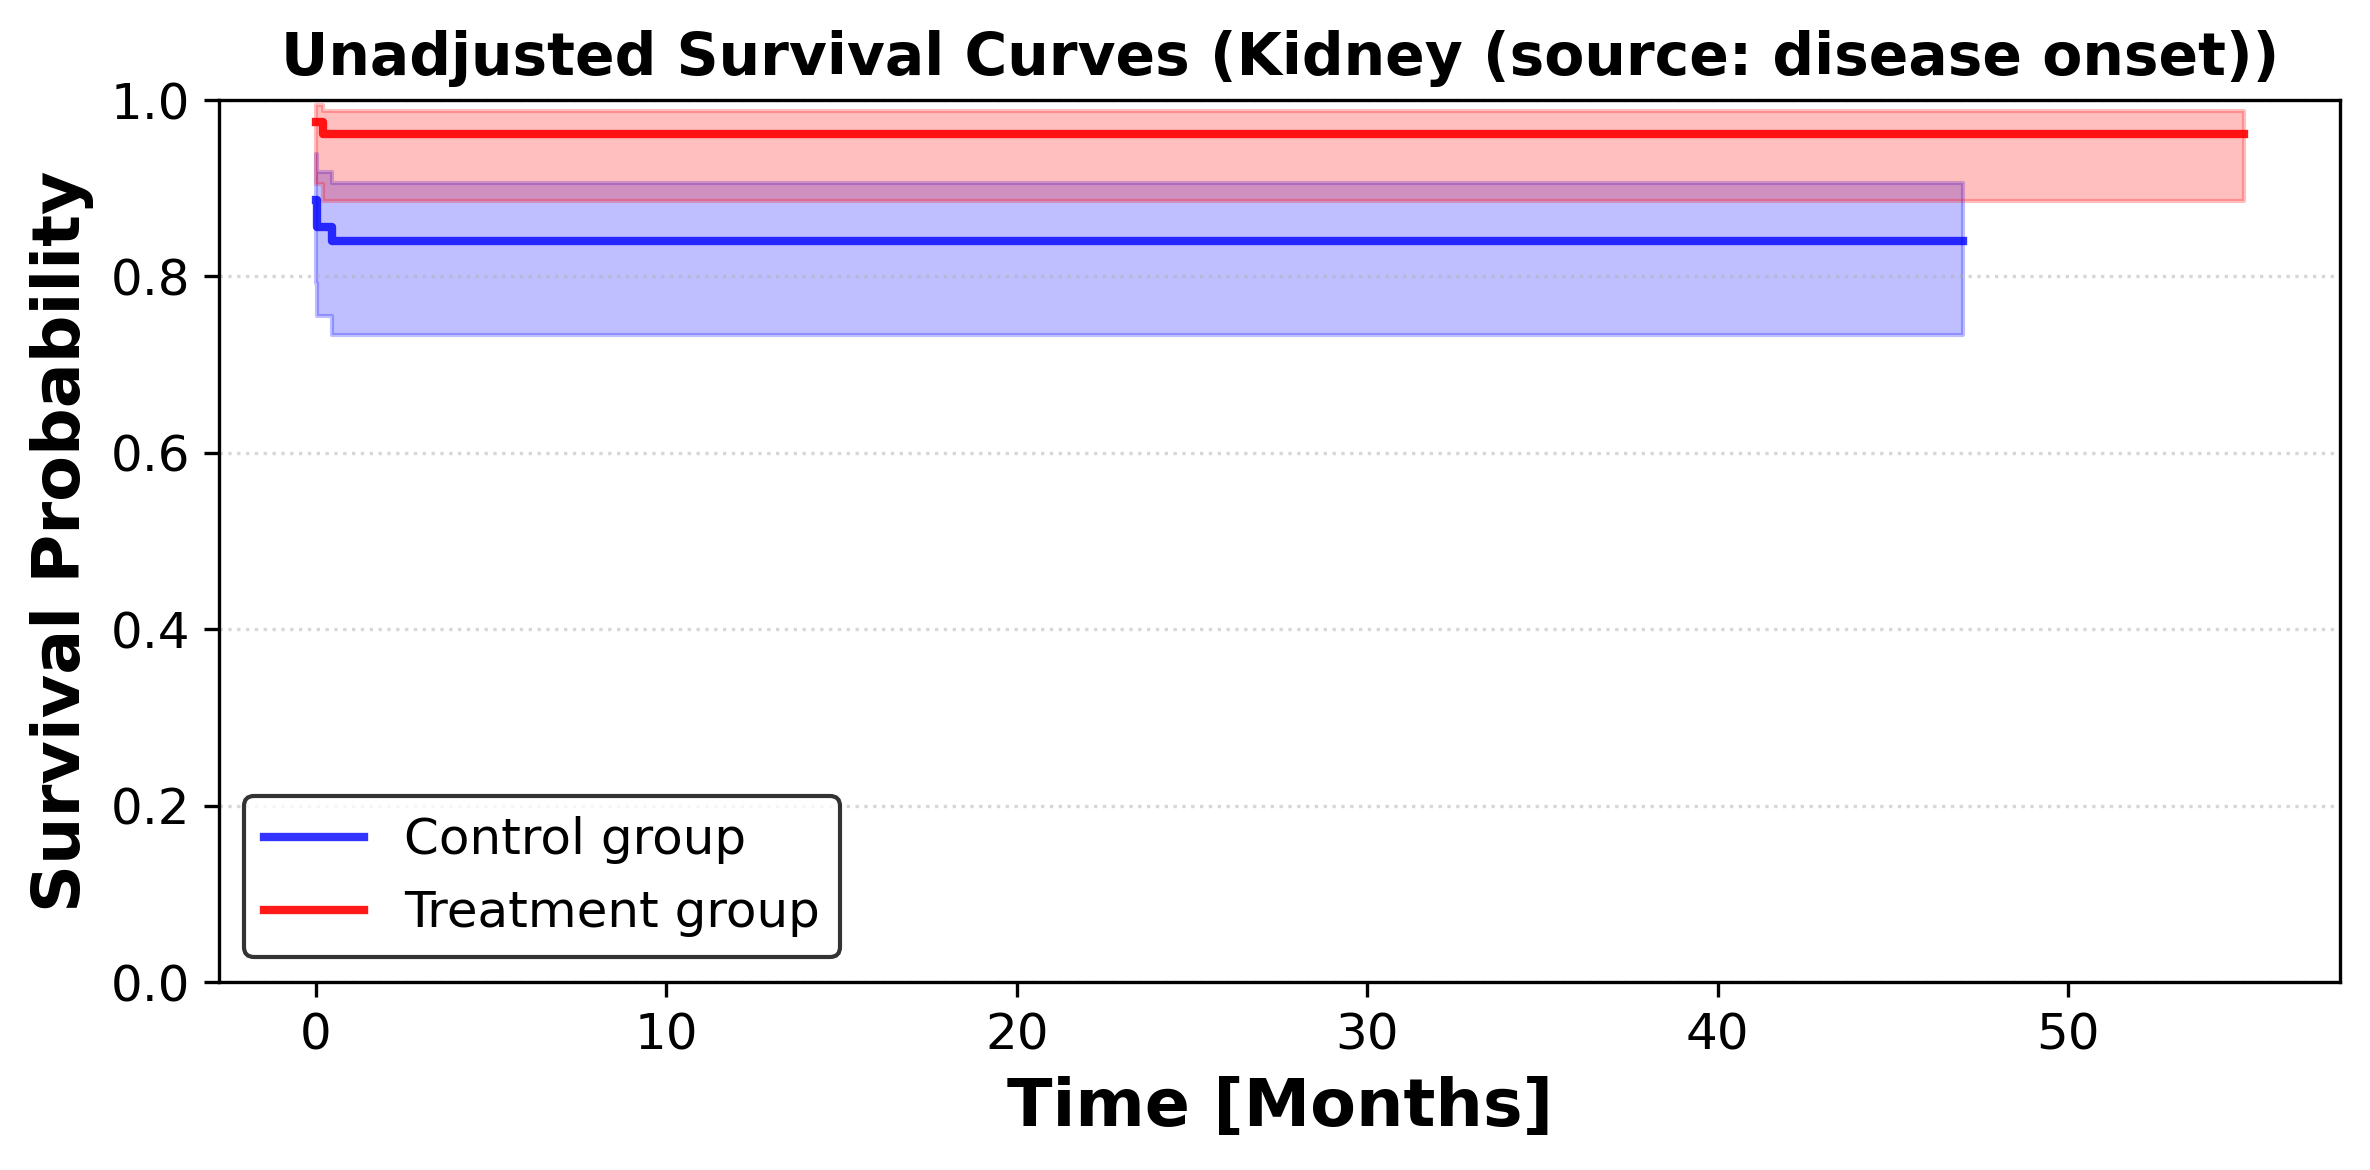

In [174]:
from lifelines import KaplanMeierFitter

def get_unadjusted_survival_curve_paper_ready_plot(survival_data_df, title_str):
    # Set font for publication-style consistency
    # plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.size'] = 11

    # survival_data_df = pd.DataFrame({
    #     'time': causal_data_dict['Y']['total'][:, 0], 
    #     'event': causal_data_dict['Y']['total'][:, 1],
    #     'treatment': causal_data_dict['A']['total']
    # })

    kmf = KaplanMeierFitter()

    # if '.csv' in survival_data_df.filename:
    #     survival_data_df["filename"] = survival_data_df["filename"].astype(str).str.removesuffix('.csv')

    survival_data_df = filter_times(survival_data_df, time_col="time", trt_col="treatment", p=0.99)
    survival_data_df['time'] = pd.to_numeric(survival_data_df['time'], errors="coerce")
    survival_data_df = survival_data_df.dropna(subset=['time'])

    # Split into treatment and control groups
    treatment_group = survival_data_df[survival_data_df['treatment'] == 1]
    control_group = survival_data_df[survival_data_df['treatment'] == 0]

    # Set up figure with high resolution
    plt.figure(figsize=(8, 4), dpi=300)

    # Fit and plot Kaplan-Meier survival curves with improved aesthetics
    kmf.fit(durations=control_group['time'], event_observed=control_group['event'], label='Control group')
    ax = kmf.plot_survival_function(ci_show=True, linewidth=2, linestyle='-', color='blue', alpha=0.8)
    
    control_rmst = np.trapz(y=kmf.survival_function_.values.flatten(), x=kmf.survival_function_.index)

    kmf.fit(durations=treatment_group['time'], event_observed=treatment_group['event'], label='Treatment group')
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, linestyle='-', color='red', alpha=0.9)

    treatment_rmst = np.trapz(y=kmf.survival_function_.values.flatten(), x=kmf.survival_function_.index)

    # Dashed line for median survival time

    print(f"Treatment RMST: {treatment_rmst}")
    print(f"Control RMST: {control_rmst}")

    # Customize the plot with improved formatting
    plt.title(f"Unadjusted Survival Curves ({title_str})", fontsize=14, fontweight='bold')
    plt.xlabel("Time [Months]", fontsize=16, fontweight='bold')
    plt.ylabel("Survival Probability", fontsize=16, fontweight='bold')

    # Ensure proper axis scaling
    #plt.ylim(min(kmf.survival_function_.values)-0.07, 1.05)
    #plt.xlim(0, survival_data_df['time'].max())

    # Improve legend appearance
    plt.legend(fontsize=12, frameon=True, loc='best', edgecolor='black')

    # Subtle grid lines (horizontal only, for readability)
    plt.grid(axis='y', linestyle='dotted', alpha=0.5)

    # Adjust ticks for readability
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,1)

    plt.tight_layout()
    # plt.savefig('unadjusted_survival_curves.pdf', dpi=300)

    plt.show()

# Call the function
get_unadjusted_survival_curve_paper_ready_plot(resp_from_tts_final, title_str = "Kidney (source: disease onset)")

# KM estimate - adjusted for age and sex

In [34]:

def get_demo_cohort(folder_x):
    #folder_x = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/case_reports_n140/")                # path to folder with case reports
    pattern = "PMC*_body.txt" 
    
    pmc_ids_x = {
        re.search(r"(PMC\d+)", f.name).group(1)
        for f in folder_x.glob(pattern)
        if re.search(r"(PMC\d+)", f.name)
    }
    
    demo_path = "/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/demogs250420_clean2_unique.csv"
    demo_all = pd.read_csv(demo_path).rename(columns = {'X1':'Age', 'X2':'Sex', 'X3':'Ethnicity'})
    
    demo_all["PMCID"] = demo_all["case"].str.replace(r".*/", "", regex=True)
    
    demo_all["PMCID"] = demo_all["PMCID"].str.split(".").str[0]
    demo_all["PMCID"] = demo_all["PMCID"].str.replace(r"_body$", "", regex=True)
    demo_glp = demo_all[demo_all["PMCID"].isin(pmc_ids_x)].copy().reset_index(drop = True)

    demo_glp["PMCID"] = demo_glp["PMCID"].astype(str) + "_body"

    return demo_glp

demo_case = get_demo_cohort(Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/case_reports_n140/treatment_group/"))
demo_control = get_demo_cohort(Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/case_reports_n140/control_group/"))

demo_case_control = pd.concat([demo_case, demo_control], axis=0, ignore_index=True)

# demo_case["PMCID"] = demo_case["PMCID"].astype(str) + "_body"
# demo_control["PMCID"] = demo_control["PMCID"].astype(str) + "_body"



In [82]:
# # demo_case_control = pd.concat([demo_case, demo_control], axis=0, ignore_index=True)

# df = kidney_from_tts_final.merge(demo_case_control[["Age", "Sex", "PMCID"]], left_on = "filename", right_on = "PMCID", how = "inner")

# df.dropna(subset = ["Age"])


Treatment HR = 61794368.979 (95% CI 0.000–inf), p = 0.996


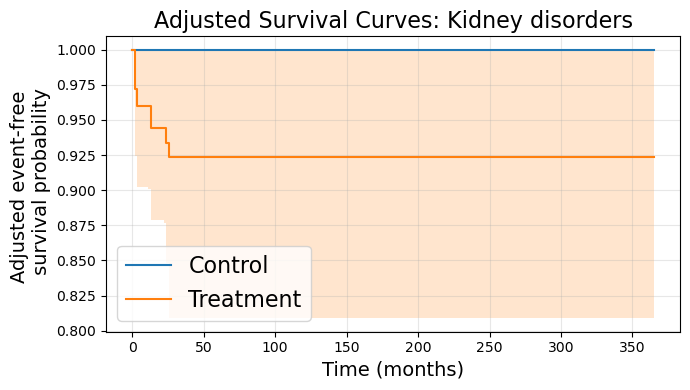

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter

def plot_km_and_adjusted_cox_bootstrap_ci(
    df,
    time_col="time",
    event_col="event",
    trt_col="treatment",
    age_col="Age",
    sex_col="Sex",
    n_boot=300,          # increase to 1000 for smoother CI
    random_state=0,
    plot_title = "",
):
    # ---------- Clean/prepare ----------
    d0 = df[[time_col, event_col, trt_col, age_col, sex_col]].copy()

    d0[time_col]  = pd.to_numeric(d0[time_col], errors="coerce")
    d0[event_col] = pd.to_numeric(d0[event_col], errors="coerce")
    d0[trt_col]   = pd.to_numeric(d0[trt_col], errors="coerce")
    d0[age_col]   = pd.to_numeric(d0[age_col], errors="coerce")
    d0[sex_col]   = d0[sex_col].astype(str).str.strip()

    d0 = d0.dropna(subset=[time_col, event_col, trt_col, age_col, sex_col]).copy()
    d0[event_col] = d0[event_col].astype(int)
    d0[trt_col]   = d0[trt_col].astype(int)

    # One-hot encode Sex for Cox model (drop one category)
    d = pd.get_dummies(d0, columns=[sex_col], drop_first=True)

    # ---------- Fit Cox on full data ----------
    cph = CoxPHFitter()
    cph.fit(d, duration_col=time_col, event_col=event_col)

    # Build "typical patient" covariates: mean age, modal sex dummy
    cov_cols = [c for c in d.columns if c not in [time_col, event_col]]
    base = d[cov_cols].mean(numeric_only=True)
    for col in cov_cols:
        if col.startswith(f"{sex_col}_"):
            base[col] = int(d[col].mode().iloc[0])

    x_control = base.copy(); x_control[trt_col] = 0
    x_treat   = base.copy(); x_treat[trt_col]   = 1
    X = pd.DataFrame([x_control, x_treat], index=["Control", "Treatment"])

    # Time grid for plotting (use observed time range)
    t_grid = np.linspace(0, float(d0[time_col].max()), 200)

    # Point-estimate adjusted survival
    sf_point = cph.predict_survival_function(X, times=t_grid)  # columns: Control/Treatment

    # ---------- Bootstrap CI for adjusted curves ----------
    rng = np.random.default_rng(random_state)
    surv_boot = {label: [] for label in X.index}

    n = len(d)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # bootstrap sample indices
        d_b = d.iloc[idx].reset_index(drop=True)

        try:
            cph_b = CoxPHFitter()
            cph_b.fit(d_b, duration_col=time_col, event_col=event_col)

            sf_b = cph_b.predict_survival_function(X, times=t_grid)
            for label in X.index:
                surv_boot[label].append(sf_b[label].values)
        except Exception:
            # occasionally bootstrap samples can cause convergence issues; skip those draws
            continue

    # Compute percentile bands
    ci = {}
    for label in X.index:
        arr = np.asarray(surv_boot[label])
        if arr.size == 0:
            ci[label] = (None, None)
            continue
        lower = np.percentile(arr, 2.5, axis=0)
        upper = np.percentile(arr, 97.5, axis=0)
        ci[label] = (lower, upper)

    # ---------- Plot (2 panels) ----------
    #fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig, axes =  plt.subplots(1, 1, figsize=(7, 4))

    # (1) Unadjusted KM with CI
    # ax = axes[0]
    # kmf = KaplanMeierFitter()
    # for trt_value, label in [(0, "Control"), (1, "Treatment")]:
    #     m = d0[trt_col] == trt_value
    #     kmf.fit(d0.loc[m, time_col], d0.loc[m, event_col], label=label)
    #     kmf.plot_survival_function(ax=ax, ci_show=True)
    # ax.set_title(f"Unadjusted Kaplan–Meier Curves: {plot_title}", fontsize = 16)
    # ax.set_xlabel("Time (months)", fontsize = 14)
    # ax.set_ylabel("Event-free \n survival probability", fontsize = 14)
    # ax.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)
    # ax.legend(fontsize = 16)

    # (2) Adjusted Cox curves with bootstrap CI
    ax = axes
    for label in X.index:
        ax.step(t_grid, sf_point[label].values, where="post", label=label)
        lower, upper = ci[label]
        if lower is not None:
            ax.fill_between(t_grid, lower, upper, step="post", alpha=0.2)

    ax.set_title(f"Adjusted Survival Curves: {plot_title}", fontsize = 16)
    ax.set_xlabel("Time (months)", fontsize = 14)
    ax.set_ylabel("Adjusted event-free \n survival probability", fontsize = 14)
    ax.grid(True, alpha=0.3)
    #ax.set_ylim(0.5,1)
    ax.legend(fontsize = 16)

    plt.tight_layout()

    #plt.savefig("/Users/kumars33/Desktop/Diabetes_LLM_annotation/GLP_AMIA/paper_plots/cardio_cox_survival.pdf", dpi = 300, bbox_inches='tight')
    #plt.show()

    return cph




#---------- Usage ----------

df = kidney_from_tts_final.merge(demo_case_control[["Age", "Sex", "PMCID"]], left_on = "filename", right_on = "PMCID", how = "inner").dropna(subset = ["Age"]).reset_index(drop = True)

df_new = df.loc[~((df["event"] == 1) & (df["time"] == 0))].copy()

cph_model = plot_km_and_adjusted_cox_bootstrap_ci(df_new, n_boot=500, plot_title = "Kidney disorders")
#print(cph_model.summary)

s = cph_model.summary

hr = s.loc["treatment", "exp(coef)"]
hr_lo = s.loc["treatment", "exp(coef) lower 95%"]
hr_hi = s.loc["treatment", "exp(coef) upper 95%"]
pval = s.loc["treatment", "p"]

print(f"Treatment HR = {hr:.3f} (95% CI {hr_lo:.3f}–{hr_hi:.3f}), p = {pval:.3f}")



In [37]:
s = cph_model.summary

hr = s.loc["treatment", "exp(coef)"]
hr_lo = s.loc["treatment", "exp(coef) lower 95%"]
hr_hi = s.loc["treatment", "exp(coef) upper 95%"]
pval = s.loc["treatment", "p"]

print(f"Treatment HR = {hr:.3f} (95% CI {hr_lo:.3f}–{hr_hi:.3f}), p = {pval:.3f}")

Treatment HR = 0.416 (95% CI 0.107–1.610), p = 0.204


In [222]:
# cardio_from_tts_final.assign(time=pd.to_numeric(df["time"], errors="coerce")) \
#   .groupby(["treatment"]) \
#   .apply(lambda x: pd.Series({
#       "n": len(x),
#       "events_total": int((x["event"]==1).sum()),
#       "events_time0": int(((x["event"]==1) & (x["time"]==0)).sum()),
#       "censored_time0": int(((x["event"]==0) & (x["time"]==0)).sum()),
#       "min_time_event": float(x.loc[x["event"]==1, "time"].min()) if (x["event"]==1).any() else np.nan
#   }))

kidney_from_tts_final.loc[(kidney_from_tts_final.event == 1) & (kidney_from_tts_final.time != 0)]

,filename,event,time,treatment
4,PMC10301860_body,1,12.857143,1
19,PMC10997393_body,1,0.142857,1
49,PMC7454490_body,1,0.857143,1
59,PMC8312112_body,1,3.5,1
70,PMC9188737_body,1,0.047619,1
78,PMC9794239_body,1,25.0,1
129,PMC5425930_body,1,1.571429,0



[Diagnostics after filtering]
              n  events_total  events_time0  censored_time0  min_time_event
treatment                                                                  
0          68.0           3.0           0.0            28.0        0.008333
1          67.0           0.0           0.0            23.0             NaN


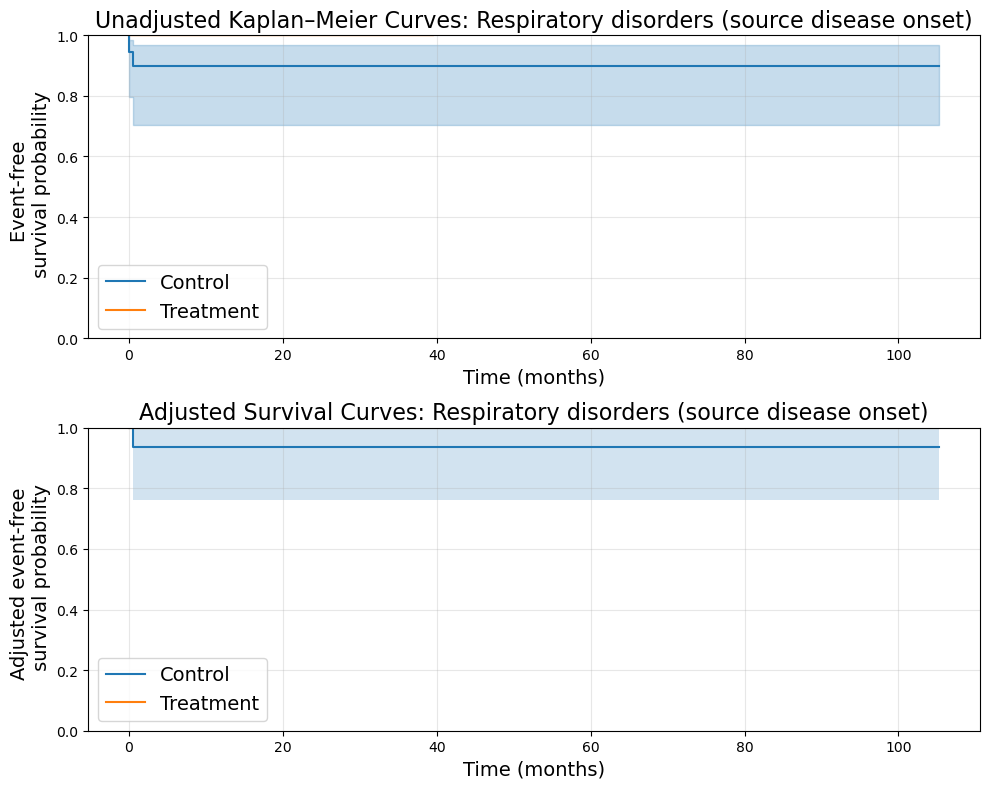


Treatment HR = 0.000 (95% CI 0.000–inf), p = 0.995
                coef     exp(coef)     se(coef)  coef lower 95%  \
covariate                                                         
treatment -17.186469  3.435669e-08  2972.055749    -5842.308696   
Age        -0.008428  9.916075e-01     0.026288       -0.059952   
Sex_Male   -0.778119  4.592691e-01     1.228766       -3.186456   

           coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to  \
covariate                                                                     
treatment     5807.935758             0.000000                  inf     0.0   
Age              0.043096             0.941810             1.044038     0.0   
Sex_Male         1.630218             0.041318             5.104988     0.0   

                  z         p  -log2(p)  
covariate                                
treatment -0.005783  0.995386  0.006672  
Age       -0.320599  0.748514  0.417899  
Sex_Male  -0.633252  0.526569  0.925306  


In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

def plot_km_and_adjusted_cox_bootstrap_ci_incident(
    df,
    id_col="filename",
    time_col="time",
    event_col="event",
    trt_col="treatment",
    age_col="Age",
    sex_col="Sex",
    exclude_time0_events=True,
    drop_time0_censored=False,
    epsilon=1e-6,
    n_boot=300,
    random_state=0,
    plot_title="",
):
    # ---------- Clean/prepare ----------
    d0 = df[[id_col, time_col, event_col, trt_col, age_col, sex_col]].copy()

    d0[time_col]  = pd.to_numeric(d0[time_col], errors="coerce")
    d0[event_col] = pd.to_numeric(d0[event_col], errors="coerce")
    d0[trt_col]   = pd.to_numeric(d0[trt_col], errors="coerce")
    d0[age_col]   = pd.to_numeric(d0[age_col], errors="coerce")
    d0[sex_col]   = d0[sex_col].astype(str).str.strip()
    d0[id_col]    = d0[id_col].astype(str)

    d0 = d0.dropna(subset=[id_col, time_col, event_col, trt_col, age_col, sex_col]).copy()
    d0[event_col] = d0[event_col].astype(int)
    d0[trt_col]   = d0[trt_col].astype(int)

    # ---------- Exclude baseline prevalent events (event==1 at time==0) ----------
    if exclude_time0_events:
        prevalent_ids = d0.loc[(d0[event_col] == 1) & (d0[time_col] == 0), id_col].unique()
        d0 = d0[~d0[id_col].isin(prevalent_ids)].copy()
    else:
        d0.loc[(d0[event_col] == 1) & (d0[time_col] == 0), time_col] = epsilon

    # ---------- Optionally drop censored-at-time0 ----------
    if drop_time0_censored:
        d0 = d0[~((d0[event_col] == 0) & (d0[time_col] == 0))].copy()

    d0 = d0[d0[time_col] >= 0].copy()

    # ---------- Diagnostics ----------
    diag = (
        d0.groupby(trt_col)
          .apply(lambda x: pd.Series({
              "n": len(x),
              "events_total": int((x[event_col] == 1).sum()),
              "events_time0": int(((x[event_col] == 1) & (x[time_col] == 0)).sum()),
              "censored_time0": int(((x[event_col] == 0) & (x[time_col] == 0)).sum()),
              "min_time_event": float(x.loc[x[event_col] == 1, time_col].min()) if (x[event_col] == 1).any() else np.nan
          }))
    )
    print("\n[Diagnostics after filtering]")
    print(diag)

    # ---------- Build Cox modeling frame (DROP id_col!) ----------
    d_model = d0.drop(columns=[id_col]).copy()
    d_model = pd.get_dummies(d_model, columns=[sex_col], drop_first=True)

    # Fit Cox
    cph = CoxPHFitter()
    cph.fit(d_model, duration_col=time_col, event_col=event_col)

    # Typical patient covariates (exclude time/event)
    cov_cols = [c for c in d_model.columns if c not in [time_col, event_col]]
    base = d_model[cov_cols].mean(numeric_only=True)

    # For sex dummy columns, set to mode
    for col in cov_cols:
        if col.startswith(f"{sex_col}_"):
            base[col] = int(d_model[col].mode().iloc[0])

    x_control = base.copy(); x_control[trt_col] = 0
    x_treat   = base.copy(); x_treat[trt_col]   = 1
    X = pd.DataFrame([x_control, x_treat], index=["Control", "Treatment"])

    # Time grid
    t_max = float(d0[time_col].max())
    t_grid = np.linspace(0, t_max, 200)

    # Point estimate adjusted survival
    sf_point = cph.predict_survival_function(X, times=t_grid)

    # Bootstrap CI for adjusted curves
    rng = np.random.default_rng(random_state)
    surv_boot = {label: [] for label in X.index}
    n = len(d_model)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d_b = d_model.iloc[idx].reset_index(drop=True)
        try:
            cph_b = CoxPHFitter()
            cph_b.fit(d_b, duration_col=time_col, event_col=event_col)
            sf_b = cph_b.predict_survival_function(X, times=t_grid)
            for label in X.index:
                surv_boot[label].append(sf_b[label].values)
        except Exception:
            continue

    ci = {}
    for label in X.index:
        arr = np.asarray(surv_boot[label])
        if arr.size == 0:
            ci[label] = (None, None)
        else:
            ci[label] = (np.percentile(arr, 2.5, axis=0),
                         np.percentile(arr, 97.5, axis=0))

    # ---------- Plot ----------
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Unadjusted KM
    ax = axes[0]
    kmf = KaplanMeierFitter()
    for trt_value, label in [(0, "Control"), (1, "Treatment")]:
        m = d0[trt_col] == trt_value
        kmf.fit(d0.loc[m, time_col], d0.loc[m, event_col], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True)

    ax.set_title(f"Unadjusted Kaplan–Meier Curves: {plot_title}", fontsize=16)
    ax.set_xlabel("Time (months)", fontsize=14)
    ax.set_ylabel("Event-free \n survival probability", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=14)

    # Adjusted Cox with bootstrap CI
    ax = axes[1]
    for label in X.index:
        ax.step(t_grid, sf_point[label].values, where="post", label=label)
        lower, upper = ci[label]
        if lower is not None:
            ax.fill_between(t_grid, lower, upper, step="post", alpha=0.2)

    ax.set_title(f"Adjusted Survival Curves: {plot_title}", fontsize=16)
    ax.set_xlabel("Time (months)", fontsize=14)
    ax.set_ylabel("Adjusted event-free \n survival probability", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=14)

    plt.tight_layout()
    plt.show()

    # Print treatment HR
    s = cph.summary
    if trt_col in s.index:
        hr = s.loc[trt_col, "exp(coef)"]
        hr_lo = s.loc[trt_col, "exp(coef) lower 95%"]
        hr_hi = s.loc[trt_col, "exp(coef) upper 95%"]
        pval = s.loc[trt_col, "p"]
        print(f"\nTreatment HR = {hr:.3f} (95% CI {hr_lo:.3f}–{hr_hi:.3f}), p = {pval:.3f}")

    return cph, d0


### ---------------- Example usage ----------------
df = resp_from_disease_onset_final.merge(
    demo_case_control[["Age", "Sex", "PMCID"]],
    left_on="filename", right_on="PMCID", how="inner"
).dropna(subset=["Age"]).reset_index(drop=True)

cph_model, df_used = plot_km_and_adjusted_cox_bootstrap_ci_incident(
    df,
    id_col="filename",
    n_boot=500,
    plot_title="Respiratory disorders (source disease onset)",
    exclude_time0_events=True,     # <-- makes curves start at 1
    drop_time0_censored=False,     # set True if you want to remove no-followup subjects
)
print(cph_model.summary)

In [146]:
print(df_used["treatment"].value_counts())
print(df_used.groupby("treatment")["event"].agg(n="count", events="sum"))
print(df_used.groupby("treatment")["time"].agg(min="min", median="median", max="max"))

treatment
0    68
1    67
Name: count, dtype: int64
            n  events
treatment            
0          68       3
1          67       0
           min    median         max
treatment                           
0          0.0  0.041667  105.333333
1          0.0  0.100000   39.500000


In [38]:
# bsv_folder = Path("/Users/kumars33/Desktop/CHARM_MIMIC/DS_survival_analysis_25k/DS_sampled_25k_timeord/clean/")

# #X = final_case_files  # e.g., ["123", "456"]
# Y = final_control_files  # e.g., ["789", "999"]

# #out_X = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/treatment_group/")
# out_Y = Path("/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/LLM_anns/gpt5_tts/control_group/")

# #out_X.mkdir(parents=True, exist_ok=True)
# out_Y.mkdir(parents=True, exist_ok=True)

# for fp in sorted(bsv_folder.glob("*")):
#     if fp.is_dir():
#         continue

#     text = fp.read_text(encoding="utf-8", errors="replace")

#     fname = fp.name
#     fstem = fp.stem

#     # if fstem in X_set:
#     #     shutil.copy2(fp, out_X / fp.name)
#     if fstem in Y_set:
#         shutil.copy2(fp, out_Y / fp.name)